# TMC vs. baselines -- run on every dataset

Trains our TMC model (`TMC ICLR/train.py`) and 5 baselines ported from
[OverfitFlow/Trust4Conflict](https://github.com/OverfitFlow/Trust4Conflict) (ICML 2025) --
**ETMC, TF, ETF, CCML, ECML**, implemented in `TMC ICLR/baselines.py` -- against every dataset in
`TMC ICLR/datasets/`, then reports accuracy side by side.

Both `data.py`'s loader and `baselines.py`'s models are dataset-shape-agnostic (views/classes/dims
are read off whatever `.mat` file loads), so nothing here is dataset-specific.

In [1]:
import os
import sys
import time
from types import SimpleNamespace

import torch    
import pandas as pd
from tqdm.auto import tqdm

PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), "TMC ICLR"))
assert os.path.isdir(PROJECT_DIR), f"TMC ICLR directory not found at {PROJECT_DIR}"
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

import train as T
import baselines as B

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

dataset_names = T.list_dataset_names()
print(f"{len(dataset_names)} dataset files:", dataset_names)

device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
27 dataset files: ['100Leaves', '3Sources', 'ACM', 'ALOI', 'BBC4view', 'BBCSport', 'Caltech101-7', 'CiteSeer', 'Cora', 'Handwritten', 'MNIST-10k', 'MNIST-4', 'MSRC-v5', 'Movies', 'NUS-WIDE', 'OutdoorScene', 'Prokaryotic', 'ProteinFold', 'Reuters-1200', 'Reuters-1500', 'UCI', 'WebKB', 'Wikipedia', 'Wikipedia-test', 'Yale', 'handwritten_6views', 'scene15']


## Config

One switch controls both sections. `QUICK_MODE=True` is a fast sanity pass (everything trains in
well under a minute per dataset); flip to `False` for the full published hyperparameters -- TMC's
full sweep alone takes roughly an hour, and the baselines add more on top of that, so don't flip it
without expecting a long run.

**Budget note:** TMC and the baselines use different training procedures (TMC: cross-fit + reliability
heads + final training; TF/ETF: warmup + func + refer + func), so "quick" and "full" here are matched
in spirit (same order of magnitude), not epoch-for-epoch identical -- the comparison table below is
informative, not a perfectly controlled benchmark.

Every stage trains for its full fixed epoch budget; the model used for the reported `test_acc` is
whatever that last epoch produced -- no validation-based early stopping or restoring.

**Checkpoint saving:** a stratified `val_size` slice of each dataset's training split (never trained
on, never the test set) scores every epoch purely so the best-scoring checkpoint can be saved to disk
alongside the final-epoch one, under `checkpoint_dir` -- two `.pt` files per run
(`<dataset>_<model>_last.pt` / `_best.pt`). This doesn't change training duration or which model is
reported as "the" result; `best_epoch`/`best_val_acc`/`best_test_acc` in the results are purely
informational, for comparing the best-validation checkpoint against the final one after the fact.

In [2]:
QUICK_MODE = False
CHECKPOINT_DIR = "checkpoints"

if QUICK_MODE:
    tmc_hparams = dict(batch_size=200, epochs=5, lambda_epochs=50, lr=0.0003,
                        k_folds=2, fold_epochs=3, reliability_epochs=3,
                        val_size=0.15, checkpoint_dir=CHECKPOINT_DIR)
    baseline_hparams = dict(batch_size=200, lr=1e-2, rlr=3e-3, warm_epochs=1,
                             smooth_factor=0.9, lambda_epochs=10, epochs=3,
                             val_size=0.15, checkpoint_dir=CHECKPOINT_DIR)
else:
    tmc_hparams = dict(batch_size=200, epochs=500, lambda_epochs=50, lr=0.0003,
                        k_folds=5, fold_epochs=100, reliability_epochs=50,
                        val_size=0.15, checkpoint_dir=CHECKPOINT_DIR)
    baseline_hparams = dict(batch_size=200, lr=1e-2, rlr=3e-3, warm_epochs=1,
                             smooth_factor=0.9, lambda_epochs=10, epochs=500,
                             val_size=0.15, checkpoint_dir=CHECKPOINT_DIR)

print("tmc_hparams:", tmc_hparams)
print("baseline_hparams:", baseline_hparams)

tmc_hparams: {'batch_size': 200, 'epochs': 500, 'lambda_epochs': 50, 'lr': 0.0003, 'k_folds': 5, 'fold_epochs': 100, 'reliability_epochs': 50, 'val_size': 0.15, 'checkpoint_dir': 'checkpoints'}
baseline_hparams: {'batch_size': 200, 'lr': 0.01, 'rlr': 0.003, 'warm_epochs': 1, 'smooth_factor': 0.9, 'lambda_epochs': 10, 'epochs': 500, 'val_size': 0.15, 'checkpoint_dir': 'checkpoints'}


## Run TMC (ours)

In [3]:
tmc_results = []
sweep_bar = tqdm(dataset_names, desc="TMC (ours)", unit="dataset")
for name in sweep_bar:
    sweep_bar.set_postfix(dataset=name)
    args = SimpleNamespace(data_name=name, data_path=f"datasets/{name}", **tmc_hparams)
    t0 = time.time()
    try:
        _, metrics = T.run_pipeline(args, device=DEVICE, verbose=False)
        metrics["model"], metrics["status"] = "TMC (ours)", "OK"
    except Exception as e:
        metrics = {"dataset": name, "model": "TMC (ours)", "status": "FAILED",
                   "error": f"{type(e).__name__}: {e}", "elapsed_sec": time.time() - t0}
    tmc_results.append(metrics)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

n_ok = sum(1 for r in tmc_results if r["status"] == "OK")
print(f"TMC (ours): {n_ok}/{len(dataset_names)} datasets OK")

TMC (ours):   0%|          | 0/27 [00:00<?, ?dataset/s]

[100Leaves] pipeline:   0%|          | 0/3 [00:00<?, ?stage/s]

cross-fit folds:   0%|          | 0/5 [00:00<?, ?fold/s]

  fold 1/5 epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

  fold 2/5 epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

...

  fold 4/5 epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

  fold 5/5 epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

reliability heads:   0%|          | 0/50 [00:00<?, ?epoch/s]

  final training epochs:   0%|          | 0/500 [00:00<?, ?epoch/s]

TMC (ours): 26/27 datasets OK


## Run baselines

In [4]:
baseline_results = []
model_bar = tqdm(B.BASELINE_NAMES, desc="baselines", unit="model")
for model_name in model_bar:
    model_bar.set_postfix(model=model_name)
    sweep_bar = tqdm(dataset_names, desc=model_name, unit="dataset", leave=False)
    for name in sweep_bar:
        sweep_bar.set_postfix(dataset=name)
        args = SimpleNamespace(data_name=name, data_path=f"datasets/{name}", **baseline_hparams)
        t0 = time.time()
        try:
            _, metrics = B.run_baseline_pipeline(args, model_name, device=DEVICE, verbose=False)
            metrics["status"] = "OK"
        except Exception as e:
            metrics = {"dataset": name, "model": model_name, "status": "FAILED",
                       "error": f"{type(e).__name__}: {e}", "elapsed_sec": time.time() - t0}
        baseline_results.append(metrics)
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    n_ok = sum(1 for r in baseline_results if r["model"] == model_name and r["status"] == "OK")
    print(f"{model_name:<6} {n_ok}/{len(dataset_names)} datasets OK")
    

baselines:   0%|          | 0/5 [00:00<?, ?model/s]

ETMC:   0%|          | 0/27 [00:00<?, ?dataset/s]

[ETMC/100Leaves] pipeline:   0%|          | 0/1 [00:00<?, ?stage/s]

[ETMC/100Leaves] func_net:   0%|          | 0/500 [00:00<?, ?epoch/s]

[ETMC/3Sources] pipeline:   0%|          | 0/1 [00:00<?, ?stage/s]

...

[ECML/handwritten_6views] pipeline:   0%|          | 0/1 [00:00<?, ?stage/s]

[ECML/handwritten_6views]:   0%|          | 0/500 [00:00<?, ?epoch/s]

[ECML/scene15] pipeline:   0%|          | 0/1 [00:00<?, ?stage/s]

[ECML/scene15]:   0%|          | 0/500 [00:00<?, ?epoch/s]

ECML   26/27 datasets OK


## Results

In [5]:
combined_df = pd.DataFrame(tmc_results + baseline_results)

csv_path = os.path.join(PROJECT_DIR, "comparison_report.csv")
combined_df.to_csv(csv_path, index=False)
print("saved to", csv_path)

pivot = combined_df[combined_df["status"] == "OK"].pivot_table(
    index="dataset", columns="model", values="test_acc"
)

method_order = ["TMC (ours)"] + B.BASELINE_NAMES
pivot = pivot[[c for c in method_order if c in pivot.columns]]
pivot.loc["mean"] = pivot.mean()

failed = combined_df[combined_df["status"] == "FAILED"][["dataset", "model", "error"]]

if len(failed):
    print(f"{len(failed)} failed run(s):")
    for _, row in failed.drop_duplicates("dataset").iterrows():
        print(f"  {row['dataset']}: {row['error']}")

pivot.round(3)

saved to e:\SanjeevSir\TMC ICLR\comparison_report.csv
13 failed run(s):
  BBC4view: TypeError: Expecting miMATRIX type here, got 2119843088
  ACM: ValueError: Input contains infinity or a value too large for dtype('float32').
  Caltech101-7: ValueError: Input contains infinity or a value too large for dtype('float32').
  Handwritten: ValueError: Input contains infinity or a value too large for dtype('float32').
  UCI: ValueError: Input contains infinity or a value too large for dtype('float32').
  Yale: ValueError: Input contains infinity or a value too large for dtype('float32').
  handwritten_6views: ValueError: Input contains infinity or a value too large for dtype('float32').
  scene15: ValueError: Input contains infinity or a value too large for dtype('float32').


model,TMC (ours),ETMC,TF,ETF,CCML,ECML
dataset,,,,,,
100Leaves,0.750,0.981,0.938,0.991,0.981,0.947
3Sources,0.853,0.882,0.853,0.853,0.882,0.853
ACM,0.940,0.936,0.926,0.929,NaN,0.932
ALOI,0.571,0.954,0.913,0.965,0.953,0.927
BBCSport,0.954,0.982,0.982,0.972,0.982,0.972
Caltech101-7,0.939,0.959,0.973,0.956,NaN,0.939
CiteSeer,0.732,0.739,0.745,0.739,0.744,0.716
Cora,0.797,0.845,0.830,0.825,0.841,0.801
Handwritten,0.978,0.982,0.980,0.975,NaN,0.978


## Best model overall

Ranks methods by mean accuracy across datasets and by win-rate (how often a method is the single
best performer on a given dataset) -- these can disagree, since a high mean can be driven by a few
standout datasets while rarely being the outright best. `pivot.mean()`/comparisons below skip `NaN`s
(failed runs) automatically, so a method with fewer successful datasets is only judged on the ones it
actually completed -- worth keeping in mind since CCML failed on several datasets above (inf/NaN
evidence under the full 500-epoch budget, a numerical stability issue in its power-sharpening step,
not fixed here).

In [6]:
per_dataset = pivot.drop("mean")
mean_acc = pivot.loc["mean"].sort_values(ascending=False)
coverage = per_dataset.count()  # datasets each method actually completed
win_counts = per_dataset.idxmax(axis=1).value_counts().reindex(mean_acc.index, fill_value=0)

best_by_mean = mean_acc.idxmax()
best_by_wins = win_counts.idxmax()

print("ranked by mean accuracy:")
for m in mean_acc.index:
    print(f"  {m:<12} mean={mean_acc[m]:.4f}   wins={win_counts[m]:<3d}  "
          f"coverage={coverage[m]}/{len(per_dataset)}")

print(f"\nbest by mean accuracy: {best_by_mean} ({mean_acc[best_by_mean]:.4f})")
print(f"best by win-rate:      {best_by_wins} ({win_counts[best_by_wins]}/{len(per_dataset)} datasets)")
if best_by_mean != best_by_wins:
    print("-> these disagree: the mean-accuracy leader isn't the most frequent single-best performer.")

BEST_MODEL = best_by_mean
best_col = per_dataset[BEST_MODEL].dropna().sort_values()
print(f"\n{BEST_MODEL}'s worst datasets:\n{best_col.head(3)}")
print(f"\n{BEST_MODEL}'s best datasets:\n{best_col.tail(3)}")

ranked by mean accuracy:
  ETF          mean=0.8253   wins=6    coverage=26/26
  ETMC         mean=0.8221   wins=9    coverage=26/26
  TF           mean=0.8147   wins=5    coverage=26/26
  ECML         mean=0.8038   wins=1    coverage=26/26
  CCML         mean=0.7775   wins=1    coverage=19/26
  TMC (ours)   mean=0.7586   wins=4    coverage=26/26

best by mean accuracy: ETF (0.8253)
best by win-rate:      ETMC (9/26 datasets)
-> these disagree: the mean-accuracy leader isn't the most frequent single-best performer.

ETF's worst datasets:
dataset
Movies         0.370968
NUS-WIDE       0.458333
ProteinFold    0.525180
Name: ETF, dtype: float64

ETF's best datasets:
dataset
handwritten_6views    0.990000
WebKB                 0.990521
100Leaves             0.990625
Name: ETF, dtype: float64


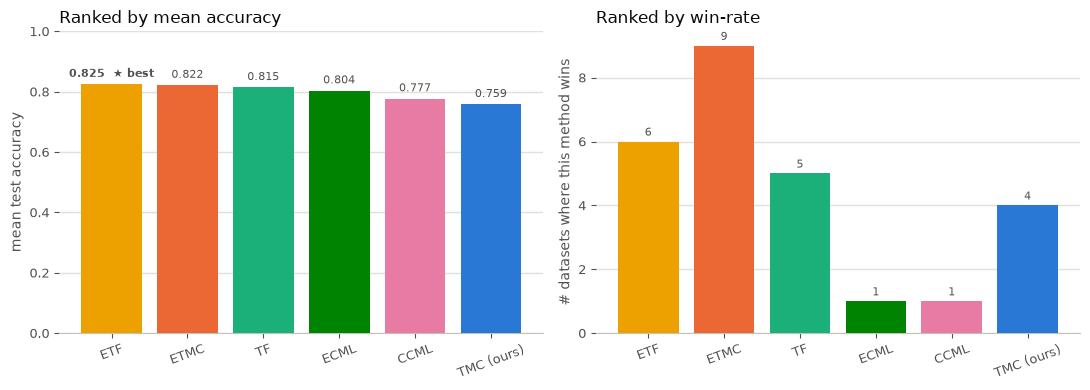

In [7]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, GRIDLINE, BASELINE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
# Fixed categorical order/hues (not cycled) -- color follows method identity
# throughout this section, never rank, so the "best" bar isn't recolored.
CATEGORICAL = {
    "TMC (ours)": "#2a78d6", "ETMC": "#eb6834", "TF": "#1baf7a",
    "ETF": "#eda100", "CCML": "#e87ba4", "ECML": "#008300",
}


def _style_axis(ax):
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(colors=INK_SECONDARY, labelsize=9)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

bars1 = ax1.bar(mean_acc.index, mean_acc.values, color=[CATEGORICAL[m] for m in mean_acc.index], zorder=3)
ax1.set_ylim(0, 1)
ax1.set_ylabel("mean test accuracy", color=INK_SECONDARY)
ax1.set_title("Ranked by mean accuracy", color=INK_PRIMARY, fontsize=12, loc="left")
_style_axis(ax1)
for bar, m in zip(bars1, mean_acc.index):
    label = f"{mean_acc[m]:.3f}" + ("  ★ best" if m == BEST_MODEL else "")
    ax1.text(bar.get_x() + bar.get_width() / 2, mean_acc[m] + 0.015, label,
              ha="center", va="bottom", fontsize=8, color=INK_SECONDARY,
              fontweight="bold" if m == BEST_MODEL else "normal")

bars2 = ax2.bar(win_counts.index, win_counts.values, color=[CATEGORICAL[m] for m in win_counts.index], zorder=3)
ax2.set_ylabel("# datasets where this method wins", color=INK_SECONDARY)
ax2.set_title("Ranked by win-rate", color=INK_PRIMARY, fontsize=12, loc="left")
_style_axis(ax2)
for bar, m in zip(bars2, win_counts.index):
    ax2.text(bar.get_x() + bar.get_width() / 2, win_counts[m] + 0.1, str(win_counts[m]),
              ha="center", va="bottom", fontsize=8, color=INK_SECONDARY)

for ax in (ax1, ax2):
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### `BEST_MODEL`'s accuracy per dataset, vs. TMC (ours)

Two series now (identity matters, not just magnitude), so both get their fixed categorical color plus
a legend -- `BEST_MODEL`'s own hue from the ranking above, TMC (ours) always blue as a constant
reference point.

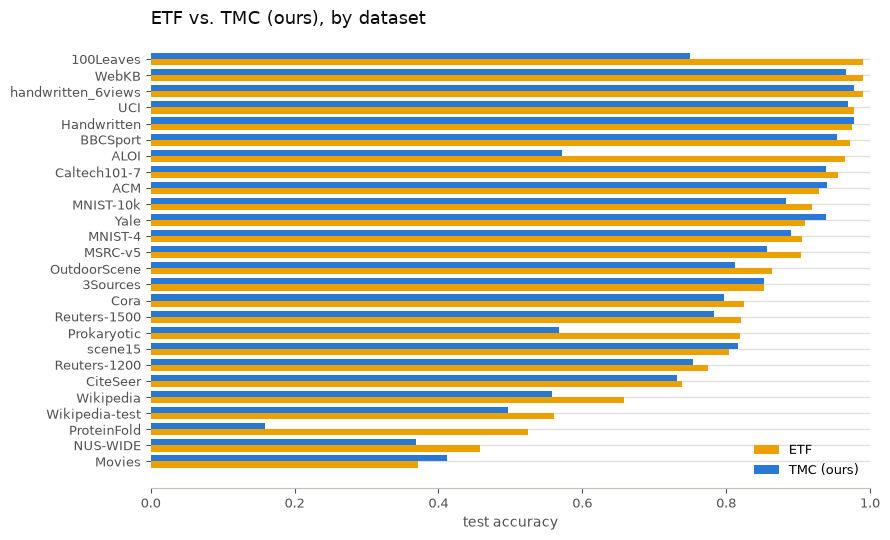

In [8]:
import numpy as np

order = per_dataset[BEST_MODEL].sort_values().index
x = np.arange(len(order))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(x - width / 2, per_dataset.loc[order, BEST_MODEL], height=width,
        color=CATEGORICAL[BEST_MODEL], label=BEST_MODEL, zorder=3)
ax.barh(x + width / 2, per_dataset.loc[order, "TMC (ours)"], height=width,
        color=CATEGORICAL["TMC (ours)"], label="TMC (ours)", zorder=3)

ax.set_yticks(x)
ax.set_yticklabels(order, fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel("test accuracy", color=INK_SECONDARY)
ax.set_title(f"{BEST_MODEL} vs. TMC (ours), by dataset", color=INK_PRIMARY, fontsize=13, loc="left")
_style_axis(ax)
ax.spines["left"].set_visible(False)
ax.legend(frameon=False, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()